##
### Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.

**Deep Learning** is a subset of **machine learning** that uses **artificial neural networks with multiple hidden layers** to automatically learn hierarchical representations from large volumes of data.

**Evolution:**
It evolved from **perceptrons and shallow neural networks**, gaining success with increased **computational power (GPUs)**, large datasets, and improved algorithms like **backpropagation and ReLU**.
<br><br>
**Difference from Traditional ML:**
Traditional ML relies on **manual feature engineering**, while deep learning **automatically learns features**, excels on **unstructured data** (images, text, audio), and typically requires **more data and computation**.

<br><br>


### Difference between Traditional Machine Learning and Deep Learning

| **Aspect**                           | **Traditional Machine Learning**       | **Deep Learning**                      |
| ------------------------------------ | -------------------------------------- | -------------------------------------- |
| **Feature Engineering**              | Manual feature extraction required     | Features learned automatically         |
| **Model Depth**                      | Shallow models (few layers)            | Deep neural networks (many layers)     |
| **Data Requirement**                 | Works well with small–medium datasets  | Requires large datasets                |
| **Computational Power**              | Lower computational needs              | High compute (GPUs/TPUs)               |
| **Performance on Unstructured Data** | Limited (text, images, audio)          | Excellent for unstructured data        |
| **Interpretability**                 | More interpretable                     | Often less interpretable (“black box”) |
| **Examples**                         | Linear Regression, SVM, Decision Trees | CNNs, RNNs, Transformers               |


##
### Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?

A **Perceptron** is the simplest neural network model used for **binary classification**. It consists of **input nodes**, **weights**, a **bias**, a **summation unit**, and an **activation function** (usually a step function).

**Functioning:**
Inputs are multiplied by weights, summed with a bias, and passed through an activation function to produce an output. During training, weights are updated based on prediction errors using a learning rule.

**Limitations:**

* Can only learn **linearly separable** problems
* Fails on problems like **XOR**
* Uses simple activation functions, limiting representational power


##
### Question 3: Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.


### **Purpose of Activation Function**

Activation functions introduce **non-linearity** into neural networks, allowing them to learn **complex patterns**. Without them, even deep networks would behave like **linear models**.

---

### **Comparison of Sigmoid, Tanh, and ReLU Activation Functions**

| **Aspect**              | **Sigmoid**               | **Tanh**                     | **ReLU**                         |
| ----------------------- | ------------------------- | ---------------------------- | -------------------------------- |
| **Formula**             | 1 / (1 + e⁻ˣ)             | (eˣ − e⁻ˣ) / (eˣ + e⁻ˣ)      | max(0, x)                        |
| **Output Range**        | 0 to 1                    | −1 to 1                      | 0 to ∞                           |
| **Zero-Centered**       | ❌ No                      | ✅ Yes                        | ❌ No                             |
| **Vanishing Gradient**  | High                      | Moderate                     | Low (for x > 0)                  |
| **Computational Speed** | Slow                      | Moderate                     | Fast                             |
| **Main Limitation**     | Saturation, slow learning | Still saturates              | Dying ReLU                       |
| **Typical Usage**       | Binary output layer       | Hidden layers (older models) | Hidden layers (modern deep nets) |

---

✅ **Key Takeaway:**

* **ReLU** is preferred in deep networks for efficiency.
* **Sigmoid** suits probability outputs.
* **Tanh** offers zero-centered output but suffers from saturation.


##
### Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.

A **loss function** measures the error for **a single training example**, while a **cost function** represents the **aggregate error over the entire dataset** (or a batch). Both guide the optimization process during neural network training.

### Difference Between Loss Function and Cost Function

| **Aspect**            | **Loss Function**                    | **Cost Function**                       |
| --------------------- | ------------------------------------ | --------------------------------------- |
| **Definition**        | Error for one data point             | Average or total error over dataset     |
| **Scope**             | Single instance                      | Whole dataset / batch                   |
| **Purpose**           | Measures individual prediction error | Evaluates overall model performance     |
| **Usage in Training** | Used to compute gradients per sample | Used to update model parameters         |
| **Examples**          | Squared Error, Log Loss              | Mean Squared Error (MSE), Cross-Entropy |

**Examples:**


**Loss Function:**

$$
L(y, \hat{y}) = (y - \hat{y})^2
$$

**Cost Function:**

$$
J = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$



##
### Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop

**Optimizers** update the **weights and biases** of a neural network by minimizing the loss function during training. They control **how fast and in what direction** the model learns, directly affecting convergence speed and stability.

### Comparison of Optimizers

| **Aspect**                  | **Gradient Descent**    | **RMSprop**     | **Adam**                 |
| --------------------------- | ----------------------- | --------------- | ------------------------ |
| **Learning Rate**           | Fixed                   | Adaptive        | Adaptive                 |
| **Momentum**                | ❌ No                    | ❌ No            | ✅ Yes                    |
| **Handles Noisy Gradients** | Poor                    | Good            | Very Good                |
| **Convergence Speed**       | Slow                    | Faster          | Fastest                  |
| **Memory Requirement**      | Low                     | Moderate        | Higher                   |
| **Common Usage**            | Simple / small datasets | RNNs, deep nets | Most deep learning tasks |

**Summary:**

* **Gradient Descent** is simple but slow.
* **RMSprop** adapts learning rates for each parameter.
* **Adam** combines momentum + adaptive learning, making it the most widely used optimizer.


##
### Question 6: Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.

In [2]:
import numpy as np

# --- AND Gate Dataset ---
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])  # AND outputs

# --- Initialize Weights and Bias ---
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 10

# --- Step Activation Function ---
def step_function(z):
    return 1 if z >= 0 else 0

# --- Training the Perceptron ---
for _ in range(epochs):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)
        error = y[i] - y_pred
        
        # Update rule
        weights += learning_rate * error * X[i]
        bias += learning_rate * error

# --- Testing the Perceptron ---
print("Final Weights:", weights)
print("Final Bias:", bias)
print("\nPredictions:")
for i in range(len(X)):
    output = step_function(np.dot(X[i], weights) + bias)
    print(f"Input: {X[i]} -> Output: {output}")


Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004

Predictions:
Input: [0 0] -> Output: 0
Input: [0 1] -> Output: 0
Input: [1 0] -> Output: 0
Input: [1 1] -> Output: 1


##
### Question 7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib

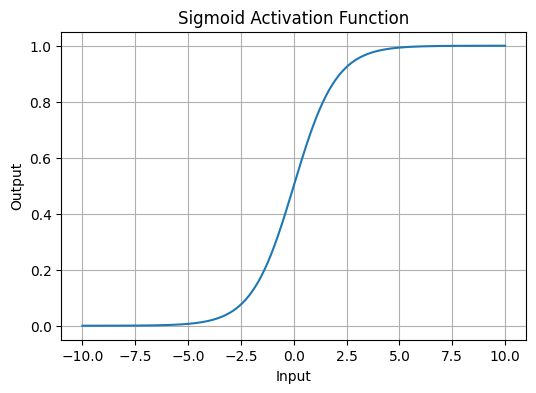

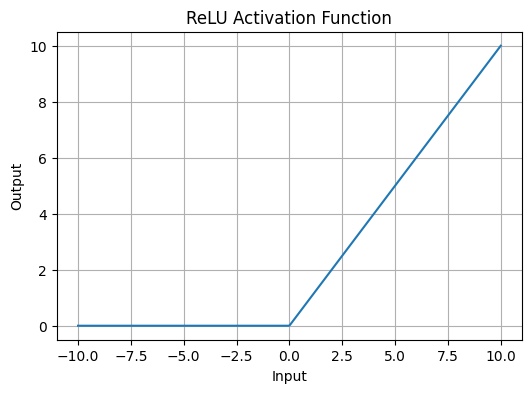

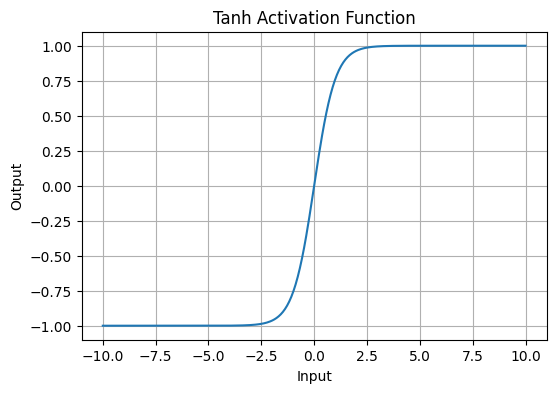

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Input Range ---
x = np.linspace(-10, 10, 400)

# --- Activation Functions ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# --- Plot Sigmoid ---
plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid(x))
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

# --- Plot ReLU ---
plt.figure(figsize=(6, 4))
plt.plot(x, relu(x))
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

# --- Plot Tanh ---
plt.figure(figsize=(6, 4))
plt.plot(x, tanh(x))
plt.title("Tanh Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()


##
### Question 8: Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.

In [3]:
# --- Import Libraries ---
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings("ignore")

# --- Load MNIST Dataset ---
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# --- Normalize Data ---
X_train = X_train / 255.0
X_test = X_test / 255.0

# --- One-hot Encode Labels ---
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# --- Build Neural Network ---
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# --- Compile Model ---
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Train Model ---
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    verbose=1
)

# --- Print Training Accuracy ---
train_accuracy = history.history['accuracy'][-1]
print(f"Training Accuracy: {train_accuracy:.4f}")


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9060 - loss: 0.3324
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9602 - loss: 0.1357
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9719 - loss: 0.0943
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9779 - loss: 0.0722
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9824 - loss: 0.0567
Training Accuracy: 0.9824
